# Superstore pandas 分析練習

這份 notebook 的目標不是背 pandas 語法，而是模仿分析師的工作流程：

1. 先理解資料長什麼樣。
2. 再看有哪些欄位。
3. 然後提出分析問題。
4. 把人類問題翻成 pandas code。
5. 最後把結果翻成可以理解的結論。

本次分析問題：

- 這份 Superstore 資料長什麼樣？
- 哪個產品類別最賺錢？
- 哪個地區最賺錢？
- 哪些訂單虧錢？
- 折扣是否可能影響利潤？

## 1. 載入工具

人類思路：

我要使用 pandas 處理表格資料，也要使用 Path 處理檔案路徑。

- `pandas`：Python 裡最常用的表格資料分析工具。
- `pd`：pandas 的慣用簡寫。
- `Path`：用來表示檔案位置，比直接操作字串更清楚。

In [1]:
import pandas as pd
from pathlib import Path

## 2. 指定 CSV 檔案位置

人類思路：

讀資料前，我要先確認資料檔在哪裡。

`data_file` 是一個變數，代表 `superstore.csv` 的位置。

`data_file.exists()` 會檢查這個檔案是否真的存在：

- `True`：找得到檔案，可以繼續讀 CSV。
- `False`：找不到檔案，路徑需要修正。

In [2]:
data_file = Path("/Users/xuweijin/Code study/python_supply_chain_learning/03_data/superstore.csv")

data_file.exists()

True

## 3. 讀取 CSV

人類思路：

現在把 CSV 讀進 pandas，變成一張可以分析的表格。

`df` 是 DataFrame 的常用名字。DataFrame 可以想成 Python 裡的 Excel 表格。

In [3]:
df = pd.read_csv(data_file)

## 4. 先看前幾筆資料

人類思路：

分析師拿到資料後，不會馬上做複雜分析。第一步是先看資料長什麼樣。

我要觀察：

- 每一列看起來代表什麼？
- 每一欄是什麼意思？
- 數字看起來合理嗎？
- 有哪些欄位可能適合拿來分組？

In [4]:
df.head()

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,...,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit
0,1,CA-2017-152156,11/8/2017,11/11/2017,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420.0,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600,2.0,0.00,41.9136
1,2,CA-2017-152156,11/8/2017,11/11/2017,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420.0,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400,3.0,0.00,219.5820
2,3,CA-2017-138688,6/12/2017,6/16/2017,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,...,90036.0,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200,2.0,0.00,6.8714
3,4,US-2016-108966,10/11/2016,10/18/2016,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311.0,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775,5.0,0.45,-383.0310
4,5,US-2016-108966,10/11/2016,10/18/2016,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311.0,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680,2.0,0.20,2.5164


## 5. 看資料大小

人類思路：

我想知道這份資料有幾列、幾欄。

`df.shape` 的格式是：

```text
(列數, 欄位數)
```

這可以幫我判斷資料規模。

In [5]:
df.shape

(10800, 21)

## 6. 看欄位名稱

人類思路：

欄位名稱決定我可以問哪些分析問題。

例如：

- `Category`：可以分析產品類別。
- `Region`：可以分析地區。
- `Sales`：可以分析銷售額。
- `Profit`：可以分析利潤。
- `Discount`：可以分析折扣。

In [6]:
df.columns.tolist()

['Row ID',
 'Order ID',
 'Order Date',
 'Ship Date',
 'Ship Mode',
 'Customer ID',
 'Customer Name',
 'Segment',
 'Country',
 'City',
 'State',
 'Postal Code',
 'Region',
 'Product ID',
 'Category',
 'Sub-Category',
 'Product Name',
 'Sales',
 'Quantity',
 'Discount',
 'Profit']

## 7. 檢查資料型態

人類思路：

我要知道每個欄位是文字、數字，還是日期。

`df.info()` 可以看到：

- 每個欄位的名稱。
- 每個欄位有多少非空值。
- 每個欄位的資料型態。

常見型態：

- `object`：通常是文字。
- `int64`：整數。
- `float64`：小數。

日期欄位有時候一開始會被 pandas 當成文字，需要之後再轉成日期。

In [7]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 10800 entries, 0 to 10799
Data columns (total 21 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Row ID         10800 non-null  str    
 1   Order ID       10800 non-null  str    
 2   Order Date     9994 non-null   str    
 3   Ship Date      9994 non-null   str    
 4   Ship Mode      9994 non-null   str    
 5   Customer ID    9994 non-null   str    
 6   Customer Name  9994 non-null   str    
 7   Segment        9994 non-null   str    
 8   Country        9994 non-null   str    
 9   City           9994 non-null   str    
 10  State          9994 non-null   str    
 11  Postal Code    9983 non-null   float64
 12  Region         9994 non-null   str    
 13  Product ID     9994 non-null   str    
 14  Category       9994 non-null   str    
 15  Sub-Category   9994 non-null   str    
 16  Product Name   9994 non-null   str    
 17  Sales          9994 non-null   float64
 18  Quantity       99

## 8. 分析問題一：哪個產品類別最賺錢？

人類思路：

我要知道每個 `Category` 的總銷售額和總利潤。

翻成 pandas：

- `groupby("Category")`：按照產品類別分組。
- `[["Sales", "Profit"]]`：只看銷售額和利潤欄位。
- `.sum()`：每一組加總。
- `.sort_values("Profit", ascending=False)`：按照利潤由高到低排序。

In [8]:
category_summary = (
    df.groupby("Category")[["Sales", "Profit"]]
    .sum()
    .sort_values("Profit", ascending=False)
)

category_summary

,Sales,Profit
Category,,
Technology,836154.0330,145454.9481
Office Supplies,719047.0320,122490.8008
Furniture,741999.7953,18451.2728


## 9. 分析問題二：哪個地區最賺錢？

人類思路：

這次邏輯跟產品類別分析一樣，只是把分組欄位從 `Category` 換成 `Region`。

這是 pandas 很重要的能力：同一種分析邏輯，可以換不同欄位重複使用。

In [9]:
region_summary = (
    df.groupby("Region")[["Sales", "Profit"]]
    .sum()
    .sort_values("Profit", ascending=False)
)

region_summary

,Sales,Profit
Region,,
West,725457.8245,108418.4489
East,678781.2400,91522.7800
South,391721.9050,46749.4303
Central,501239.8908,39706.3625


## 10. 分析問題三：哪些訂單在虧錢？

人類思路：

`Profit < 0` 代表這筆訂單虧錢。

我要先篩選出虧損訂單，再按照 `Profit` 從小到大排序，找出虧最多的訂單。

In [10]:
loss_orders = df[df["Profit"] < 0]

loss_orders[
    ["Order ID", "Category", "Sub-Category", "Product Name", "Sales", "Discount", "Profit"]
].sort_values("Profit").head(10)

,Order ID,Category,Sub-Category,Product Name,Sales,Discount,Profit
7772,CA-2017-108196,Technology,Machines,Cubify CubeX 3D Printer Double Head Print,4499.985,0.7,-6599.9780
683,US-2018-168116,Technology,Machines,Cubify CubeX 3D Printer Triple Head Print,7999.980,0.5,-3839.9904
9774,CA-2015-169019,Office Supplies,Binders,GBC DocuBind P400 Electric Binding System,2177.584,0.8,-3701.8928
3011,CA-2018-134845,Technology,Machines,Lexmark MX611dhe Monochrome Laser Printer,2549.985,0.7,-3399.9800
4991,US-2018-122714,Office Supplies,Binders,Ibico EPK-21 Electric Binding System,1889.990,0.8,-2929.4845
3151,CA-2016-147830,Technology,Machines,Cubify CubeX 3D Printer Double Head Print,1799.994,0.7,-2639.9912
5310,CA-2018-131254,Office Supplies,Binders,Fellowes PB500 Electric Punch Plastic Comb Bin...,1525.188,0.8,-2287.7820
9639,CA-2016-116638,Furniture,Tables,Chromcraft Bull-Nose Wood Oval Conference Tabl...,4297.644,0.4,-1862.3124
1199,CA-2017-130946,Office Supplies,Binders,GBC DocuBind P400 Electric Binding System,1088.792,0.8,-1850.9464
2697,CA-2015-145317,Technology,Machines,Cisco TelePresence System EX90 Videoconferenci...,22638.480,0.5,-1811.0784


## 11. 分析問題四：折扣是否可能影響利潤？

人類思路：

我想初步觀察折扣和利潤的關係。

這裡先做簡單版本：

- 按照 `Discount` 分組。
- 加總 `Sales` 和 `Profit`。
- 按照 `Profit` 排序。

注意：這只能說明折扣和利潤可能有關，還不能直接說折扣造成虧損。

In [11]:
discount_summary = (
    df.groupby("Discount")[["Sales", "Profit"]]
    .sum()
    .sort_values("Profit")
)

discount_summary.head(10)

,Sales,Profit
Discount,,
0.70,40620.2820,-40075.3569
0.80,16963.7560,-30539.0392
0.40,116417.7840,-23057.0504
0.50,58918.5400,-20506.4281
0.30,103226.6550,-10369.2774
0.60,6644.7000,-5944.6552
0.45,5484.9740,-2493.1111
0.32,14493.4588,-2391.1377
0.15,27558.5215,1418.9915


## 12. 用人話輸出初步結論

人類思路：

分析師最後不能只丟表格，還要把結果變成句子。

這一步會輸出：

- 最賺錢的產品類別。
- 最賺錢的地區。
- 虧損訂單數量。

In [12]:
best_category = category_summary.index[0]
best_category_profit = category_summary.iloc[0]["Profit"]

best_region = region_summary.index[0]
best_region_profit = region_summary.iloc[0]["Profit"]

print(f"Best category by profit: {best_category} (${best_category_profit:,.2f})")
print(f"Best region by profit: {best_region} (${best_region_profit:,.2f})")
print(f"Number of loss-making rows: {len(loss_orders)}")

Best category by profit: Technology ($145,454.95)
Best region by profit: West ($108,418.45)
Number of loss-making rows: 1871


## 13. 學習檢查

跑完後，回頭問自己：

1. `df` 是什麼？
2. `df.head()` 讓我看到什麼？
3. `df.shape` 的兩個數字分別代表什麼？
4. `groupby("Category")` 的人類意思是什麼？
5. 為什麼分析師最後要用句子輸出結論？

下一步練習：

把 `Category` 改成 `Sub-Category`，看看哪個子類別最賺錢。

## 14. 進階：真正分析師會做到哪個步驟？

基礎版做到「會算答案」；真正的分析師要再往前做到「能判斷這個答案可不可信，並且能提出下一步行動」。

實務上通常會走到這些步驟：

1. 定義商業問題：這次到底要回答利潤、銷售、折扣、地區，還是產品問題？
2. 檢查資料品質：缺值、型態、日期、重複資料、異常值。
3. 建立分析欄位：毛利率、出貨天數、月份、是否虧損、折扣等級。
4. 看整體 KPI：總銷售、總利潤、利潤率、虧損比例。
5. 分層比較：產品類別、子類別、地區、客群、折扣區間。
6. 找問題清單：不是只看最高，也要找出拖累利潤的產品、地區、折扣組合。
7. 看時間趨勢：問題是長期存在，還是某幾個月突然發生？
8. 輸出結論與建議：把表格翻成「我建議公司做什麼」。

這份 notebook 的進階目標是做到第 8 步：可以交出一份初版分析結論。

## 15. 先做資料品質檢查

人類思路：

在進階分析裡，不能直接相信資料。我要先知道哪些欄位有缺值，缺多少。

這一步不是為了馬上刪資料，而是先評估資料是否可靠。

In [13]:
missing_report = (
    df.isna()
    .sum()
    .to_frame("missing_rows")
    .assign(missing_rate=lambda x: x["missing_rows"] / len(df))
    .query("missing_rows > 0")
    .sort_values("missing_rows", ascending=False)
)

missing_report

,missing_rows,missing_rate
Postal Code,817,0.075648
Region,806,0.074630
Discount,806,0.074630
Quantity,806,0.074630
Sales,806,0.074630
Product Name,806,0.074630
Sub-Category,806,0.074630
Category,806,0.074630
Product ID,806,0.074630
Order Date,806,0.074630


## 16. 建立乾淨的分析資料表

人類思路：

我不直接覆蓋原本的 `df`，而是建立 `analysis_df`。這樣原始資料還留著，分析資料則可以清理和新增欄位。

這裡會做幾件事：

- 移除關鍵欄位缺值的列。
- 把訂單日期和出貨日期轉成真正的日期格式。
- 新增出貨天數、利潤率、訂單月份、是否虧損、折扣等級。

In [14]:
analysis_df = df.copy()

required_columns = [
    "Order Date",
    "Ship Date",
    "Category",
    "Sub-Category",
    "Region",
    "Segment",
    "Sales",
    "Quantity",
    "Discount",
    "Profit",
]

analysis_df = analysis_df.dropna(subset=required_columns).copy()

analysis_df["Order Date"] = pd.to_datetime(analysis_df["Order Date"], errors="coerce")
analysis_df["Ship Date"] = pd.to_datetime(analysis_df["Ship Date"], errors="coerce")
analysis_df = analysis_df.dropna(subset=["Order Date", "Ship Date"]).copy()

analysis_df["Ship Days"] = (analysis_df["Ship Date"] - analysis_df["Order Date"]).dt.days
analysis_df["Profit Margin"] = analysis_df["Profit"] / analysis_df["Sales"].replace(0, pd.NA)
analysis_df["Order Month"] = analysis_df["Order Date"].dt.to_period("M").astype(str)
analysis_df["Is Loss Row"] = analysis_df["Profit"] < 0
analysis_df["Discount Level"] = pd.cut(
    analysis_df["Discount"],
    bins=[-0.01, 0, 0.2, 0.5, 1.0],
    labels=["No discount", "Low discount", "Medium discount", "High discount"],
)

analysis_df.shape

(9994, 26)

## 17. 整體 KPI：先看公司總體狀態

人類思路：

真正分析師不會一開始就只看某個產品。要先知道整體水位，後面分組分析才有比較基準。

In [15]:
total_sales = analysis_df["Sales"].sum()
total_profit = analysis_df["Profit"].sum()
total_quantity = analysis_df["Quantity"].sum()
profit_margin = total_profit / total_sales
loss_row_count = analysis_df["Is Loss Row"].sum()
loss_row_rate = loss_row_count / len(analysis_df)
average_ship_days = analysis_df["Ship Days"].mean()

print(f"Clean rows: {len(analysis_df):,}")
print(f"Total sales: ${total_sales:,.2f}")
print(f"Total profit: ${total_profit:,.2f}")
print(f"Total quantity: {total_quantity:,.0f}")
print(f"Profit margin: {profit_margin:.2%}")
print(f"Loss-making rows: {loss_row_count:,} ({loss_row_rate:.2%})")
print(f"Average ship days: {average_ship_days:.1f}")

Clean rows: 9,994
Total sales: $2,297,200.86
Total profit: $286,397.02
Total quantity: 37,873
Profit margin: 12.47%
Loss-making rows: 1,871 (18.72%)
Average ship days: 4.0


## 18. 進階 groupby：一次算多個指標

人類思路：

基礎版只加總 `Sales` 和 `Profit`。進階版會同時看銷售、利潤、數量、平均折扣和利潤率。

這樣才知道：

- 是賣得多所以賺錢？
- 還是利潤率真的好？
- 折扣是否偏高？

In [16]:
category_advanced = (
    analysis_df.groupby("Category", as_index=False)
    .agg(
        sales=("Sales", "sum"),
        profit=("Profit", "sum"),
        quantity=("Quantity", "sum"),
        average_discount=("Discount", "mean"),
    )
    .assign(profit_margin=lambda x: x["profit"] / x["sales"])
    .sort_values("profit", ascending=False)
)

category_advanced.round(
    {
        "sales": 2,
        "profit": 2,
        "average_discount": 3,
        "profit_margin": 3,
    }
)

,Category,sales,profit,quantity,average_discount,profit_margin
2,Technology,836154.03,145454.95,6939.0,0.132,0.174
1,Office Supplies,719047.03,122490.80,22906.0,0.157,0.170
0,Furniture,741999.80,18451.27,8028.0,0.174,0.025


## 19. 找出拖累利潤的子類別

人類思路：

分析師不能只報告「誰最好」，也要找出「哪裡正在傷害利潤」。

所以這裡改用 `Category + Sub-Category` 分組，並按照利潤由低到高排序。

In [17]:
subcategory_risk = (
    analysis_df.groupby(["Category", "Sub-Category"], as_index=False)
    .agg(
        order_rows=("Row ID", "count"),
        sales=("Sales", "sum"),
        profit=("Profit", "sum"),
        quantity=("Quantity", "sum"),
        average_discount=("Discount", "mean"),
        loss_rows=("Is Loss Row", "sum"),
    )
    .assign(
        profit_margin=lambda x: x["profit"] / x["sales"],
        loss_row_rate=lambda x: x["loss_rows"] / x["order_rows"],
    )
    .sort_values("profit")
)

subcategory_risk.head(10).round(
    {
        "sales": 2,
        "profit": 2,
        "average_discount": 3,
        "profit_margin": 3,
        "loss_row_rate": 3,
    }
)

,Category,Sub-Category,order_rows,sales,profit,quantity,average_discount,loss_rows,profit_margin,loss_row_rate
3,Furniture,Tables,319,206965.53,-17725.48,1241.0,0.261,203,-0.086,0.636
0,Furniture,Bookcases,228,114880.00,-3472.56,868.0,0.211,109,-0.030,0.478
12,Office Supplies,Supplies,190,46673.54,-1189.10,647.0,0.077,33,-0.025,0.174
8,Office Supplies,Fasteners,217,3024.28,949.52,914.0,0.082,12,0.314,0.055
15,Technology,Machines,115,189238.63,3384.76,440.0,0.306,44,0.018,0.383
9,Office Supplies,Labels,364,12486.31,5546.25,1400.0,0.069,0,0.444,0.000
5,Office Supplies,Art,796,27118.79,6527.79,3000.0,0.075,0,0.241,0.000
7,Office Supplies,Envelopes,254,16476.40,6964.18,906.0,0.080,0,0.423,0.000
2,Furniture,Furnishings,957,91705.16,13059.14,3563.0,0.138,167,0.142,0.175
4,Office Supplies,Appliances,466,107532.16,18138.01,1729.0,0.167,67,0.169,0.144


## 20. 交叉表：找出產品類別和地區的組合問題

人類思路：

有時候某個產品類別整體看起來還可以，但在某個地區特別差。

`pivot_table` 很像 Excel 樞紐分析表，可以快速看「類別 x 地區」的利潤分布。

In [18]:
category_region_profit = pd.pivot_table(
    analysis_df,
    index="Category",
    columns="Region",
    values="Profit",
    aggfunc="sum",
    fill_value=0,
)

category_region_profit.round(2)

Region,Central,East,South,West
Category,,,,
Furniture,-2871.05,3046.17,6771.21,11504.95
Office Supplies,8879.98,41014.58,19986.39,52609.85
Technology,33697.43,47462.04,19991.83,44303.65


## 21. 折扣分層：不要只看單一折扣數字

人類思路：

每一個折扣百分比都分開看，表格會太碎。

分析師通常會先把折扣切成幾個等級，再看每個等級的銷售、利潤、平均利潤率和虧損比例。

In [19]:
discount_level_summary = (
    analysis_df.groupby("Discount Level", observed=True)
    .agg(
        order_rows=("Row ID", "count"),
        sales=("Sales", "sum"),
        profit=("Profit", "sum"),
        average_profit_margin=("Profit Margin", "mean"),
        loss_rows=("Is Loss Row", "sum"),
    )
    .assign(loss_row_rate=lambda x: x["loss_rows"] / x["order_rows"])
    .reset_index()
    .sort_values("profit")
)

discount_level_summary.round(
    {
        "sales": 2,
        "profit": 2,
        "average_profit_margin": 3,
        "loss_row_rate": 3,
    }
)

,Discount Level,order_rows,sales,profit,average_profit_margin,loss_rows,loss_row_rate
3,High discount,856,64228.74,-76559.05,-1.139,856,1.000
2,Medium discount,537,298541.41,-58817.00,-0.220,492,0.916
1,Low discount,3803,846522.24,100785.47,0.174,523,0.138
0,No discount,4798,1087908.47,320987.60,0.340,0,0.000


## 22. 時間趨勢：看問題是否持續發生

人類思路：

如果只看總數，我不知道問題是長期存在，還是某幾個月突然變差。

所以要按月份看銷售、利潤和利潤率。

In [20]:
monthly_summary = (
    analysis_df.groupby("Order Month", as_index=False)
    .agg(
        sales=("Sales", "sum"),
        profit=("Profit", "sum"),
        quantity=("Quantity", "sum"),
    )
    .assign(profit_margin=lambda x: x["profit"] / x["sales"])
    .sort_values("Order Month")
)

monthly_summary.tail(12).round(
    {
        "sales": 2,
        "profit": 2,
        "profit_margin": 3,
    }
)

,Order Month,sales,profit,quantity,profit_margin
36,2018-01,43971.37,7140.44,597.0,0.162
37,2018-02,20301.13,1613.87,363.0,0.079
38,2018-03,58872.35,14751.89,885.0,0.251
39,2018-04,36521.54,933.29,733.0,0.026
40,2018-05,44261.11,6342.58,887.0,0.143
41,2018-06,52981.73,8223.34,931.0,0.155
42,2018-07,45264.42,6952.62,840.0,0.154
43,2018-08,63120.89,9040.96,884.0,0.143
44,2018-09,87866.65,10991.56,1660.0,0.125
45,2018-10,77776.92,9275.28,1133.0,0.119


## 23. 簡單視覺化：讓趨勢更容易被看懂

人類思路：

表格可以精準，圖表可以快速看趨勢。

這裡先畫最近 12 個月的銷售和利潤。真正報告時，圖表要搭配一句重點解讀。

Text(0, 0.5, 'Amount')

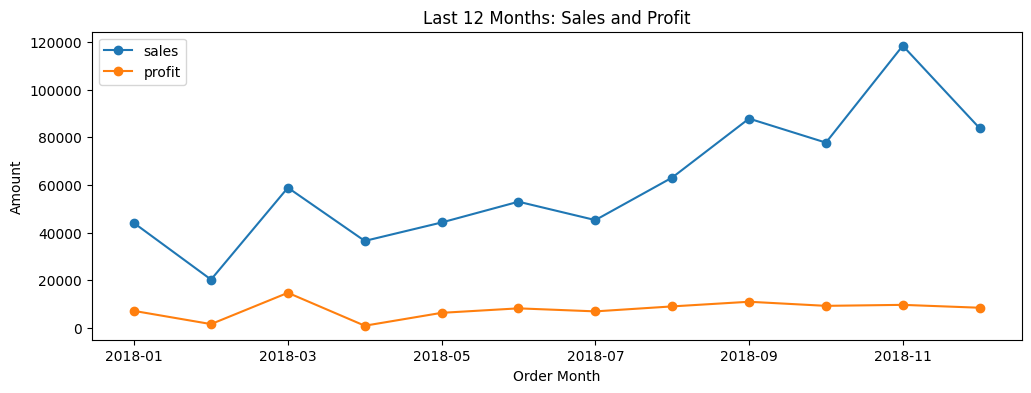

In [21]:
last_12_months = monthly_summary.tail(12)

ax = last_12_months.plot(
    x="Order Month",
    y=["sales", "profit"],
    kind="line",
    marker="o",
    figsize=(12, 4),
    title="Last 12 Months: Sales and Profit",
)

ax.set_xlabel("Order Month")
ax.set_ylabel("Amount")

## 24. 產品層級：找出最需要處理的品項

人類思路：

公司通常不能只聽「Furniture 表現差」這種大方向。

更實用的做法是列出最虧錢的產品，讓採購、訂價或營運團隊知道要優先檢查哪些品項。

In [22]:
product_profit = (
    analysis_df.groupby(["Product Name", "Category", "Sub-Category"], as_index=False)
    .agg(
        sales=("Sales", "sum"),
        profit=("Profit", "sum"),
        quantity=("Quantity", "sum"),
        average_discount=("Discount", "mean"),
    )
    .assign(profit_margin=lambda x: x["profit"] / x["sales"])
)

worst_products = product_profit.sort_values("profit").head(10)

worst_products.round(
    {
        "sales": 2,
        "profit": 2,
        "average_discount": 3,
        "profit_margin": 3,
    }
)

,Product Name,Category,Sub-Category,sales,profit,quantity,average_discount,profit_margin
475,Cubify CubeX 3D Printer Double Head Print,Technology,Machines,11099.96,-8879.97,9.0,0.533,-0.800
985,Lexmark MX611dhe Monochrome Laser Printer,Technology,Machines,16829.90,-4589.97,18.0,0.400,-0.273
476,Cubify CubeX 3D Printer Triple Head Print,Technology,Machines,7999.98,-3839.99,4.0,0.500,-0.480
425,Chromcraft Bull-Nose Wood Oval Conference Tabl...,Furniture,Tables,9917.64,-2876.12,27.0,0.280,-0.290
376,Bush Advantage Collection Racetrack Conference...,Furniture,Tables,9544.72,-1934.40,33.0,0.350,-0.203
683,GBC DocuBind P400 Electric Binding System,Office Supplies,Binders,17965.07,-1878.17,27.0,0.450,-0.105
444,Cisco TelePresence System EX90 Videoconferenci...,Technology,Machines,22638.48,-1811.08,6.0,0.500,-0.080
1043,Martin Yale Chadless Opener Electric Letter Op...,Office Supplies,Supplies,16656.20,-1299.18,22.0,0.100,-0.078
285,Balt Solid Wood Round Tables,Furniture,Tables,6518.75,-1201.06,19.0,0.200,-0.184
364,BoxOffice By Design Rectangular and Half-Moon ...,Furniture,Tables,1706.25,-1148.44,15.0,0.483,-0.673


## 25. 客群層級：同時看客戶數與客均銷售

人類思路：

客群分析不能只看總銷售，因為某個客群可能只是人多。

所以這裡同時看：

- 總銷售
- 總利潤
- 客戶數
- 利潤率
- 每位客戶平均銷售額

In [23]:
segment_summary = (
    analysis_df.groupby("Segment", as_index=False)
    .agg(
        sales=("Sales", "sum"),
        profit=("Profit", "sum"),
        quantity=("Quantity", "sum"),
        customers=("Customer ID", "nunique"),
    )
    .assign(
        profit_margin=lambda x: x["profit"] / x["sales"],
        sales_per_customer=lambda x: x["sales"] / x["customers"],
    )
    .sort_values("profit", ascending=False)
)

segment_summary.round(
    {
        "sales": 2,
        "profit": 2,
        "profit_margin": 3,
        "sales_per_customer": 2,
    }
)

,Segment,sales,profit,quantity,customers,profit_margin,sales_per_customer
0,Consumer,1161401.34,134119.21,19521.0,409,0.115,2839.61
1,Corporate,706146.37,91979.13,11608.0,236,0.130,2992.15
2,Home Office,429653.15,60298.68,6744.0,148,0.140,2903.06


## 26. 把分析翻成可以行動的結論

人類思路：

真正分析師最後要把 pandas 結果翻成商業語言。

好的初版結論通常包含：

- 發現了什麼。
- 影響有多大。
- 可能原因是什麼。
- 建議下一步檢查或行動。

注意：目前分析只能說「折扣和虧損一起出現」，不能直接說「折扣造成虧損」。要證明因果，還需要更嚴格的實驗或統計設計。

In [24]:
best_category = category_advanced.iloc[0]
weakest_subcategory = subcategory_risk.iloc[0]
worst_discount_level = discount_level_summary.iloc[0]
worst_product = product_profit.sort_values("profit").iloc[0]
best_month = monthly_summary.sort_values("profit", ascending=False).iloc[0]

print(
    f"1. 利潤最高的產品大類是 {best_category['Category']}，"
    f"利潤 ${best_category['profit']:,.2f}，"
    f"利潤率 {best_category['profit_margin']:.1%}。"
)
print(
    f"2. 最拖累利潤的子類別是 {weakest_subcategory['Sub-Category']}，"
    f"累計利潤 ${weakest_subcategory['profit']:,.2f}，"
    f"虧損列比例 {weakest_subcategory['loss_row_rate']:.1%}。"
)
print(
    f"3. 利潤最低的折扣層級是 {worst_discount_level['Discount Level']}，"
    f"累計利潤 ${worst_discount_level['profit']:,.2f}，"
    f"虧損列比例 {worst_discount_level['loss_row_rate']:.1%}。"
)
print(
    f"4. 最虧損產品是 {worst_product['Product Name']}，"
    f"累計利潤 ${worst_product['profit']:,.2f}。"
)
print(
    f"5. 利潤最高月份是 {best_month['Order Month']}，"
    f"利潤 ${best_month['profit']:,.2f}。"
)
print("下一步建議：優先檢查高折扣、Tables/Machines 類產品，以及最虧損產品的訂價和促銷規則。")

1. 利潤最高的產品大類是 Technology，利潤 $145,454.95，利潤率 17.4%。
2. 最拖累利潤的子類別是 Tables，累計利潤 $-17,725.48，虧損列比例 63.6%。
3. 利潤最低的折扣層級是 High discount，累計利潤 $-76,559.05，虧損列比例 100.0%。
4. 最虧損產品是 Cubify CubeX 3D Printer Double Head Print，累計利潤 $-8,879.97。
5. 利潤最高月份是 2017-12，利潤 $17,885.31。
下一步建議：優先檢查高折扣、Tables/Machines 類產品，以及最虧損產品的訂價和促銷規則。


## 27. 進階練習任務

如果你想練到真正分析師的程度，下一步不要只改一個欄位，而是完成一個小型分析任務：

1. 找出每個 `Region` 最虧錢的 `Sub-Category`。
2. 比較 `Discount Level` 在不同 `Region` 的利潤率。
3. 找出 2018 年利潤最低的 5 個月份或品項。
4. 選一個你認為最重要的問題，寫 3 句商業結論。
5. 在結論後面加一句「我還需要什麼資料才能更確定」。

真正的標準不是會寫多少 pandas，而是能不能從資料走到清楚、可檢查、可行動的判斷。